<br>

**Author:** Yasin Arafat <br>
**gmail:** yasinarafat.e2021@gmail.com

<br>

**topics:**
- #01:  PatchEmbed
    - Patch Partition 
    - Linear Embedding

- #02: Patch Merging

- #03: SwinTransformer block
    - WindowAttention
    - W-MSA and SW-MSA

- #04: BasicLayer
    - SwinTransformerBlock + PatchMerging

- #05: Final SwinTransformer Block


In [1]:

#%pip install --upgrade git+https://github.com/rwightman/pytorch-image-models.git
print("",end="",flush=True)


In [6]:

import random 
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.metrics import ConfusionMatrixDisplay

import torch 
import torch.nn as nn 
import torch.optim as optim 
from torch.nn import functional as F 

import torch.utils.checkpoint as checkpoint

import torchvision as vision 
import torchvision.transforms as transform 
from timm.layers import DropPath,to_2tuple, trunc_normal_


In [4]:

# seeting up the seed for reproducibility:

#for python 
random.seed(42)
#for torch
g = torch.Generator().manual_seed(42)

# seeting up the device for gpu or cpu: 
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device = torch.device(device)
device


device(type='cpu')

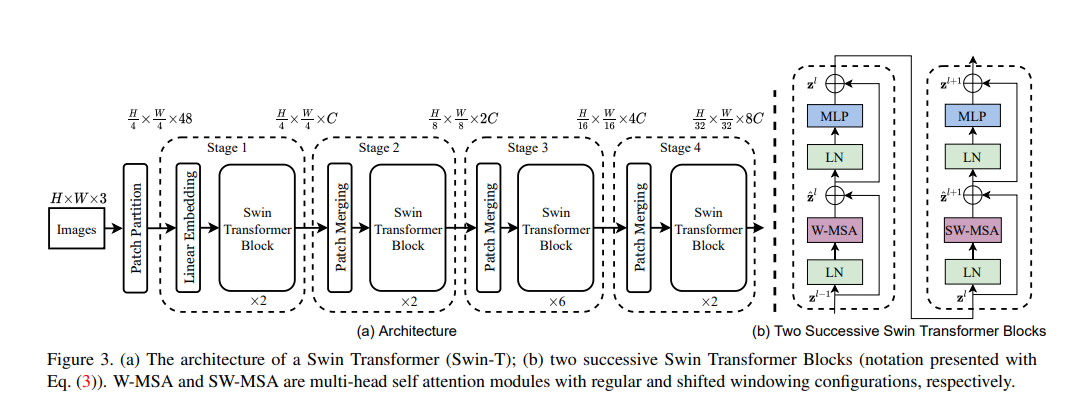

In [5]:

# architecture of swin:
from IPython.display import Image,display
display(Image("img/image.png"))

<br>
<br>

# `#01 PatchEmbed`

- Patch Partition 
- Linear Embedding

<br>
<br>

In [ ]:

class PatchEmbed(nn.Module):
    r""" Image to Patch Embedding
    Args:
        img_size (int): Image size.  Default: 224.
        patch_size (int): Patch token size. Default: 4.
        in_img_chanel (int): Number of input image channels. Default: 3.
        out_img_chanel (int): Number of linear projection output channels. Default: 96.
        norm_layer (nn.Module, optional): Normalization layer. Default: None
    """
    def __init__(self,img_size,patch_size,in_img_chanel,out_img_chanel,layer_norm:None):
        super().__init__()
        img_size = to_2tuple(img_size) #224,224
        patch_size = to_2tuple(patch_size)#4,4
        #(224/4,224/4)=(56,56)
        patch_resolution = img_size[0]//patch_size[0],img_size[1]//patch_size[1]
        
        
        self.img_size = img_size
        self.patch_size = patch_size
        self.patch_resolution = patch_resolution
        self.num_patches = patch_resolution[0] * patch_resolution[1] #56*56=3136
        
        self.in_img_chanel = in_img_chanel #3
        self.out_img_chanel = out_img_chanel #96
        
        # linear embedding part:(making patches)
        self.proj = nn.Conv2d(in_channels=in_img_chanel,out_channels=out_img_chanel,
                              kernel_size=patch_size,stride=patch_size)
        
        if layer_norm is not None:
            self.layer_norm = layer_norm(out_img_chanel)
        else:
            self.layer_norm = None
        
    def forward(self,X):
        B,C,H,W = X.shape #batch,channel,height,width,[1,3,244,244]

        assert H==self.img_size[0] and W==self.img_size[1],f"""Input image size 
        ({H},{W}) does not match model expect ({self.img_size[0]},{self.img_size[1]})"""
        
        x = self.proj(X) #1,96,56,56
        x = torch.flatten(input=x,start_dim=2) # 1,96,(56*56) = 1,96,3136
        x = x.transpose(1,2) # 1,3136,96
        return x # 1,3136,96 (Batch_size,)
    
    def flops(self):
        # conv2D: param's + output
        ph,pw = self.patch_resolution 
        flops = (self.in_img_chanel * self.out_img_chanel * self.patch_size[0] 
                 * self.patch_size[1] * ph * pw)
        
        # layer normalization
        if self.layer_norm is not None:
            # output elemnts
            flops += self.out_img_chanel * ph * pw 
        return flops 
    
    

<br>
<br>

# `#02 Patch Merging:`

<br>
<br>


In [ ]:

class PatchMerging(nn.Module):
    r""" Patch Merging Layer.
    Args:
        input_resolution (tuple[int]): Resolution of input feature.
        dim (int): Number of input channels.
        norm_layer (nn.Module, optional): Normalization layer.  Default: nn.LayerNorm
    """
    def __init__(self,input_resolution,dim,layer_norm:nn.LayerNorm):
        super().__init__()
        self.input_resolution = input_resolution
        self.dim = dim 
        self.reduction = nn.Linear(in_features=4*dim,
                                            out_features=2*dim,bias=False)
        self.layer_norm = layer_norm(4 * dim)
        
    def forward(self,x):
        H,W = self.input_resolution
        # B, H*W , C = [1, 56*56, 96]
        B,L,C = x.shape 
        
        assert L==H*W,"Input feature wrong: PachMerging"
        assert H%2==0 and W%2==0,f"size: ({H},{W}) are not even."
        
        x = x.view(B,H,W,C) #[1,56,56,96]
        
        """    H/w
        if x = 0  1  2  3
               4  5  6  7 
               8  9  10 11 
               12 13 14 15 
        x0 = 0 2
             8 10
        x1 = 4 6 
            12 14
        x2 = 1 3 
             9 11
        x3 = 5 7 
            13 15
        """
        x0 = x[:,0::2,0::2,:] # H:even W:even [1,28,28,96] skip: one value:
        x1 = x[:,1::2,0::2,:] # H:odd W:even  [1,28,28,96]
        x2 = x[:,0::2,1::2,:] # H:even W:odd  [1,28,28,96]
        x3 = x[:,1::2,1::2,:] # H:odd W:odd   [1,28,28,96]
        
        # concatinate in channel dimention(increase 4 times but we need 2 times):
        x = torch.concat(tensors=[x0,x1,x2,x3],dim=-1) #[1,28,28,4*96]
        x = x.view(1,-1,4*C)
        x = self.layer_norm(x)
        
        #reduction into: 2C,
        """ 
        Research are very smart, they just not use average them up to reduce the channel 
        dimention. What we do in pooling. They think and made it a learnable parameter.Why, 
        they do this, becuase research want to touch the dataset to make any preprocessing.
        """
        x = self.reduction(x)
        return x #1,784,192
    

<br>
<br>

# `#03 SwinTransformer block:`
<br>
<br>

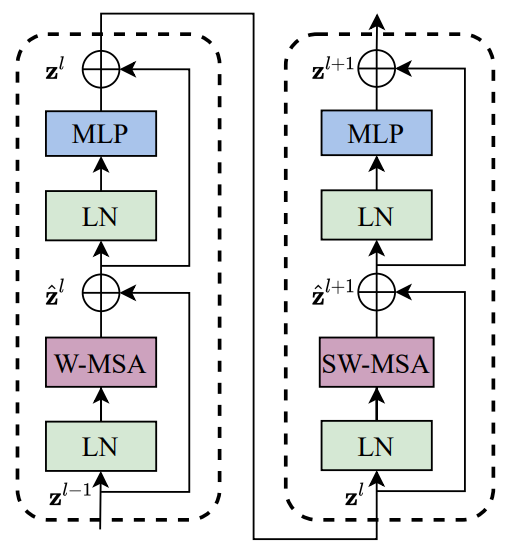

In [11]:

from IPython.display import display,Image
display(Image("img/image01.png"))


- LN (with torch nn module)
- W-MSA or SW-MSA with (WindowAttention with mask) if mask W-MSA else SW-MSA
- MLP

In [13]:

class MLP(nn.Module):
    def __init__(self,
                 in_features=None,
                 out_features=None,
                 hidden_features=None,
                 act_layer = nn.GELU,
                 drop_prob=0.):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(in_features=in_features,out_features=hidden_features),
            act_layer(),
            nn.Linear(in_features=hidden_features,out_features=out_features),
            nn.Dropout(p=drop_prob)
        )
        
    def forward(self,x):
        out = self.mlp(x)
        return out 
    
def window_partition(x,window_size):
    r""" 
        Args:
            x:(B,H,W,C)
            windows_size : int
        return:
            windows(number_of_windows*B,window_size,window_size,C)
    """
    B,H,W,C = x.shape # 1,28,28,192
    x = x.view(B,H//window_size,window_size,W//window_size,window_size,C)#1,28/ws,ws,28/ws,ws,192
    x = x.permute(0,1,3,2,4,5)#1,28/ws,28/ws,ws,ws,192 => (28/ws) * (28/ws) = total_num_window
    x = x.contiguous().view(-1,window_size,window_size,C) #(batch_size*total_num_window),ws,ws,192
    return x
    

def window_reverse(window,window_size,H,W):
    """
    Args:
        windows: (num_windows*B, window_size, window_size, C)
        window_size (int): Window size
        H (int): Height of image
        W (int): Width of image

    Returns:
        x: (B, H, W, C)
    """
    B = int(window.shape[0] / (H*W/window_size/window_size))
    x = window.view(B,H//window_size,W//window_size,window_size,window_size,-1) 
    x = x.permute(0,1,3,2,4,5)
    x = x.contiguous().view(B,H,W,-1) 
    return x #B,H,W,C

# <------------------------------------------------Window Attention------------------------------------------->
# If we give mask then it will act like: SW-MSA
# If we don't give mask then it will act as: W-MSA
class WindowAttention(nn.Module):
    r""" Window based multi-head self attention (W-MSA) module with relative position bias.
     It supports both of shifted and non-shifted window.

     Args:
        dim (int): Number of input channels.
        window_size (tuple[int]): The height and width of the window.
        num_heads (int): Number of attention heads.
        qkv_bias (bool, optional):  If True, add a learnable bias to query, key, value. Default: True
        qk_scale (float | None, optional): Override default qk scale of head_dim ** -0.5 if set
        attn_drop (float, optional): Dropout ratio of attention weight. Default: 0.0
        proj_drop (float, optional): Dropout ratio of output. Default: 0.0
    """
    def __init__(self,dim,window_size,num_heads,qkv_bias=True,attn_drop=0,proj_drop=0):
        super().__init__()
        self.dim = dim 
        self.window_size = window_size # Wh,Ww
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.scale = (self.head_dim)**(-0.5) # 1/rootover(dk) in attention formula
        self.qkv = nn.Linear(in_features=dim,out_features=3*dim,bias=qkv_bias) # c,3c
        self.linearTrnasfortn = nn.Linear(in_features=dim,out_features=dim) # c,c 
        self.softmax = nn.Softmax(dim=-1)
        self.attn_drop = nn.Dropout(attn_drop)
        self.proj_drop = nn.Dropout(proj_drop)
        
        """ 
        **Relative_Position_Bias_Table**
        In ViT we use learbale positional embedding. In swin transformer we use 
        learbale bias.
        """
        self.relative_position_bias_table = nn.Parameter(
            torch.zeros((2*window_size[0]-1) * (2*window_size[1]-1),self.num_heads))
        
        """ 
        **for relative positional bias we need to calculate relative distance**
        - How to calculate relative distance:
            - make coordiante(coords_h,coords_w) in each window
            - flatten
            - non negative shifting (difference dx=x-x or dy=y-y)
        """
        coords_h = torch.arange(self.window_size[0]) #[0,1,2,3] if window_size(4,4)
        coords_w = torch.arange(self.window_size[1]) #[0,1,2,3]
        coords = torch.stack(torch.meshgrid([coords_h,coords_w])) # 2,Wh,Ww

        #flatten_dim = 2,Wh*Ww
        coords_flatten = torch.flatten(coords,start_dim=1)
        
        #relative coordinates:(1st dim->x-value, 2nd dim->y-value,None-> add one dim(None))
        #coords_flatten(2,Wh*Ww) --to--> (2,Wh*Ww,1)
        # relative_coords: (2,Wh*Ww,1) - (2,1,Wh*ww)
        # (2,Wh*Ww,Wh*Ww)
        relative_coords = coords_flatten[:,:,None] - coords_flatten[:,None,:]
        relative_coords = relative_coords.permute(1,2,0)
        relative_coords = relative_coords.contiguous() #(Wh*Ww,Wh*Ww,2)

        # made -ve value into zero or positive: [-3,-2,-1] +3 = [0,1,2]
        relative_coords[:,:,0] += self.window_size[0] - 1
        relative_coords[:,:,1] += self.window_size[1] - 1
        
        """ 
        - with respect to dx and dy: we need to find unique relative position 
        for each token. That's why change the scale of dx 
        - Finally, add  up: (dx+dy)
        """
        relative_coords[:,:,0] *= 2*window_size[1] -1 
        relative_pos_index = relative_coords.sum(dim=-1) #(Wh*Ww,Wh*Ww)

        
        # PyTorch buffer: save this tensor as buffer but not trainbale
        self.register_buffer("relative_pos_index",relative_pos_index)
        
        """
        - relative_position_bias_table's weight and bias initilize with  (truncated normal distribution)
        - its will help to converge faster
        """
        trunc_normal_(self.relative_position_bias_table,std=0.02)
        
    def forward(self,x,mask):
        # x = ((num_windows * batch_size, Wh * Ww, C))
        B_,N,C = x.shape 
        qkv = self.qkv(x) #B_,N,3C
        qkv = qkv.view(B_,N,3,self.num_heads,self.head_dim)#B_,N,3,num_head,C//num_head
        qkv = qkv.permute(2,0,3,1,4) #3,B_,num_head,N,C//num_head
        q,k,v = qkv[0],qkv[1],qkv[2] #B_,num_head,N,C//num_head
         
        #<---------------attention score-------------------->
        # here,we are scaling the q then we do calculate attention, it will reduce the matmul computation
        q = q * self.scale
        attn = q @ k.transpose(-1,-2) #B_,num_head,N,N
        
        # <---------relative postion bias:------------------>
        relative_pos_bias = self.relative_position_bias_table[
            self.relative_pos_index.view(-1)] # Wh*Ww * Wh*Ww,num_head
        relative_pos_bias = relative_pos_bias.view(self.window_size[0]*self.window_size[1],
                                self.window_size[0]*self.window_size[1],-1) #Wh*Ww,Wh*Ww,num_head
        relative_pos_bias = relative_pos_bias.permute(2,0,1)
        relative_pos_bias = relative_pos_bias.contiguous() # num_head,Wh*Ww,Wh*Ww
        #N = Wh*Ww
        #attn: B_,num_head,N,N
        #rela_pos_bias: num_head,N,N -> unsqueeze -> 1,num_head,N,N 
        # result: B_,num_head,N,N
        attn = attn + relative_pos_bias.unsqueeze(0)
        
        #<-----------------------Masking------------------------>
        if mask is not None:
            nW = mask.shape[0] #mask: total_num_window,N,N --> nW,N,N where, N = Wh*Ww
            
            #Now, atten: B_,num_head,N,N and mask: nW,N,N 
            attn = attn.view(B_//nW,nW,self.num_heads,N,N) + mask.unsqueeze(1).unsqueeze(0)
            attn = attn.view(-1,self.num_heads,N,N)
            attn = self.softmax(attn)
        else:
            attn = self.softmax(attn)
        
        # for reduce variance: use dropout: 
        attn = self.attn_drop(attn)
        
        # multipy with value:
        # (B,head,N,N) (B_,num_head,N,head_dim) => (B,num_head,N,head_dim) transpose=> (B,N,num_head,head_dim)
        x = (attn @ v).transpose(1,2).reshape(B_,N,C) #(num_windows * batch_size, Wh * Ww, C)
        x = self.linearTrnasfortn(x) # nW*B,N,C
        x = self.proj_drop(x)
        return x 
    

#<----------------------------------------------SwinTransformerBlock------------------------------------->
class SwinTransformerBlock(nn.Module):
    r""" Swin Transformer Block.

    Args:
        dim (int): Number of input channels.
        input_resolution (tuple[int]): Input resulotion.
        num_heads (int): Number of attention heads.
        window_size (int): Window size.
        shift_size (int): Shift size for SW-MSA.
        mlp_ratio (float): Ratio of mlp hidden dim to embedding dim.
        qkv_bias (bool, optional): If True, add a learnable bias to query, key, value. Default: True
        qk_scale (float | None, optional): Override default qk scale of head_dim ** -0.5 if set.
        drop (float, optional): Dropout rate. Default: 0.0
        attn_drop (float, optional): Attention dropout rate. Default: 0.0
        drop_path (float, optional): Stochastic depth rate. Default: 0.0
        act_layer (nn.Module, optional): Activation layer. Default: nn.GELU
        norm_layer (nn.Module, optional): Normalization layer.  Default: nn.LayerNorm
        fused_window_process (bool, optional): If True, use one kernel to fused window shift &
        window partition for acceleration, similar for the reversed part. Default: False
    """
    def __init__(self,dim,input_resolution,num_head,window_size=7,
                 shift_size=0,mlp_ratio=4,qkv_bias=True,qk_scale=None,
                 drop=0,atten_drop=0,drop_path=0,activation=nn.GELU,layer_norm=nn.LayerNorm,
                 fused_window_process=False):
        super().__init__()
        self.dim = dim # 96
        self.input_resolution = input_resolution #56,56
        self.num_head = num_head # 
        self.window_size = window_size #7
        
        """ 
        - Convert Orginal Patches into Shift Patches.
        - Normaly 1/2 of the windows size.
        - If shift_size=3, the feature map is shifted 3 pixels upward and leftward with 
        Pytorch.roll()
        """
        self.shift_size = shift_size #s
        self.mlp_ratio = mlp_ratio #4
        
        # If, window_size is larger than resolution:
        if min(self.input_resolution) <= self.window_size:
            self.shift_size  = 0
            self.window_size = min(self.input_resolution)

        assert 0 <= self.shift_size < self.window_size, "shift size must be less then window size"
        """ 
        *******************************************
        ###########Follow the diagram:#############
        *******************************************
        """
        self.norm1 = layer_norm(dim)
        self.attn = WindowAttention(dim=self.dim,
                                    window_size=to_2tuple(self.window_size),
                                    num_heads=self.num_head,
                                    qkv_bias=qkv_bias,
                                    attn_drop=atten_drop,
                                    proj_drop=drop
                                    )
        
        """
        DropPath for Residual collection: (For reduce overfiting)
        - will be applied when we do add&norm with residual connection.
        - nn.Identity() no change will be happen, without changing anything forward pass the newtork
        """
        self.drop_path =  DropPath(drop_path) if drop_path>0 else nn.Identity()


        self.norm2 = layer_norm(dim)
        mlp_hidden_dim = int(mlp_ratio * dim)
        self.mlp = MLP(
            in_features=dim,
            out_features=dim,
            hidden_features=mlp_hidden_dim,
            act_layer=activation,
            drop_prob=drop
        )
        
        # shift>0 create_mask else mask=None:
        """ 
        **W-MSA:** We devide the picture into windows. Each windows calculate attention
        indenpendently.
        
        **SW-MSA:** We shift the window (top-left,top-right,left,right,up,down) for 
        shifting we need shift size.
        
        if shift_size = 0, No masking
        if shift_size != 0, Apply masking
        """
        if shift_size>0:
            H,W = self.input_resolution
            img_mask = torch.zeros(size=(1,H,W,1))
            
            # -ve index is standarad in both python and torch
            h_slice = (slice(0,-self.window_size),
                       slice(-self.window_size,-self.shift_size),
                       slice(-self.shift_size,None))
            w_slice = (slice(0,-self.window_size),
                       slice(-self.window_size,-self.shift_size),
                       slice(-self.shift_size,None))
            
            # Divide image in 9 section, and give each index a number:
            cnt = 0 
            for h in h_slice:
                for w in w_slice:
                    img_mask[:,h,w,:] = cnt 
                    cnt +=1
            
            # (total_num_windwos,window_height,windows_width,channel)
            mask_windows = window_partition(img_mask,self.window_size) # nW,wH,wW,1
            mask_windows = mask_windows.view(-1,self.window_size*self.window_size) # nW, wH*wW
            # nW,1,wH*wW - nW,wH*wW,1 = nW,wH*wW,wH*wH
            attn_mask = mask_windows.unsqueeze(1) - mask_windows.unsqueeze(2)
            # atten_mask!=0, (different window token) -> -100
            # atten_mask==0, (same token in same window) -> 0
            attn_mask = attn_mask.masked_fill(attn_mask!=0,float(-100)).masked_fill(
                attn_mask==0,float(0))
        else:
            attn_mask = None 
            
        self.register_buffer("attn_mask",attn_mask)
        self.fused_window_process = fused_window_process
    
    def forward(self,x):
        # 1,3136,96 = Batch,total_patch_num, color_channel
        H,W = self.input_resolution
        B,L,C = x.shape 
        
        assert L == H*W,"input feature is wrong size"
        
        # SwinTransformerBlock:
        residual_ = x 
        x = self.norm1(x)
        x = x.view(B, H, W, C)


        # W-MSA: (Window-Multihead-Self-Attention)
        """ 
        - We will do cyclic shift if(shift_size>0 menas windowsattention with mask --->  WS-MSA) 
         else (shift_size=0,Not<0) then we will do W-MSA
        
        - If we do WS-MSA then we must do  reverse cyclic_shift 

        - **fused_window_process:**  Always be false. For, fused_window_process 
        code is written in c++ then with a wrapper covert it python to utlize the cuda.
        But, i don't have any gpu ignore it.
        """
        if self.shift_size>0: 
            if not self.fused_window_process:
                shifted_x = torch.roll(input=x,shifts=(-self.shift_size,-self.shift_size),dims=(1,2))
                x_windows = window_partition(x=x,window_size=self.window_size) #(batch_size*total_num_window),ws,ws,c
            else:
                raise ValueError("""WindowProcess Code written in c++ (then convert it in python code) for optimize
                                  the gpu but i don't code it. so, fused_window_process should be always false.""")
        else:
            shifted_x = x
            x_windows = window_partition(shifted_x,self.window_size) #(batch_size*total_num_window),ws,ws,c
                
        # W-MSA,SW-MSA, (self,x,mask):
        x_windows = x_windows.view(-1, self.window_size * self.window_size, C)  # nW*B, window_size*window_size, C
        attn_windows = self.attn(x_windows,self.attn_mask) #(num_windows * batch_size, Wh * Ww, C), Wh=Ww=window_size
        
        # merge_window:
        attn_windows = attn_windows.view(-1,self.window_size,self.window_size,C)
        
        #reverse cyclic shift:
        if self.shift_size>0:
            if not self.fused_window_process:
                shifted_x = window_reverse(window=attn_windows,window_size=self.window_size,H=H,W=W) #B,H,W,C
                x = torch.roll(input=shifted_x,shifts=(self.shift_size,self.shift_size),dims=(1,2))
            else:
                raise ValueError("""ReverseWindowProcess Code written in c++ (then convert it in python code) for optimize
                                  the gpu but i don't code it. so, fused_window_process should be always false.
                                 """)
        else:
            shifted_x = window_reverse(window=attn_windows,window_size=self.window_size,H=H,W=W) #B,H,W,C
            x = shifted_x
            
        # add with drop_path:
        x = x.view(B, H * W, C) # for adding with residual
        x = residual_ + self.drop_path(x)
        
        # LayerNormalization + add + FFN:
        residual_ = x 
        x = residual_ + self.drop_path(self.mlp(self.norm2(x)))
        return x 
    

    

<br>
<br>

# `#04 BasicLayer:`
- Implemention of SwinTransformerBlock and PatchMerging
- From the diagram, PatchMerging is not applicable when we are at last layer of SwinTransformerBlock
<br>
<br>

In [16]:
class BasicLayer(nn.Module):
    r""" 
    A basic Swin Transformer layer for one stage.

    Args:
        dim (int): Number of input channels.
        input_resolution (tuple[int]): Input resolution.
        depth (int): Number of blocks.
        num_heads (int): Number of attention heads.
        window_size (int): Local window size.
        mlp_ratio (float): Ratio of mlp hidden dim to embedding dim.
        qkv_bias (bool, optional): If True, add a learnable bias to query, key, value. Default: True
        qk_scale (float | None, optional): Override default qk scale of head_dim ** -0.5 if set.
        drop (float, optional): Dropout rate. Default: 0.0
        attn_drop (float, optional): Attention dropout rate. Default: 0.0
        drop_path (float | tuple[float], optional): Stochastic depth rate. Default: 0.0
        norm_layer (nn.Module, optional): Normalization layer. Default: nn.LayerNorm
        downsample (nn.Module | None, optional): Downsample layer at the end of the layer. Default: None
        use_checkpoint (bool): Whether to use checkpointing to save memory. Default: False.
        fused_window_process (bool, optional): If True, use one kernel to fused window shift & 
        window partition for acceleration, similar for the reversed part. Default: False
    """
    
    def __init__(self,
                 dim,
                 input_resolution,
                 depth,
                 num_heads,
                 window_size,
                 mlp_ratio=4.,
                 qkv_bias=True,
                 qk_scale=None,
                 drop=0.,
                 attn_drop=0.,
                 drop_path=0.,
                 norm_layer=nn.LayerNorm,
                 downsample=None,
                 use_checkpoint=False,
                 fused_window_process=False):
        super().__init__()
        self.dim = dim 
        self.input_resolution = input_resolution
        self.depth = depth 
        self.use_checkpoint = use_checkpoint
        
        # swin blocks:
        self.blocks = nn.ModuleList([
            SwinTransformerBlock(dim=dim,
                                 input_resolution=input_resolution,
                                 num_head=num_heads,
                                 window_size=window_size,
                                 # Even: W-MSA, Odd: SW-MSA
                                 shift_size=0 if (i%2 ==0 ) else window_size//2,
                                 mlp_ratio=mlp_ratio,
                                 qkv_bias=qkv_bias,
                                 qk_scale=qk_scale,
                                 drop=drop,
                                 atten_drop=attn_drop,
                                 # if drop_path is a list then drop_path[i] else drop_path
                                 drop_path=drop_path[i] if isinstance(drop_path,list) else drop_path,
                                 layer_norm=norm_layer,
                                 fused_window_process=fused_window_process)
            for i in range(depth)
        ])
        
        # patch merging layer:
        if downsample is not None:
            self.downsample = downsample(self.input_resolution,self.dim,norm_layer)
        else:
            self.downsample = None 
            
    def forward(self,x):
        for blk in self.blocks:
            #  gradient checkpointing technique, which reduce  memory uses:
            if self.use_checkpoint is not None:
                x = checkpoint.checkpoint(blk,x)
            else: 
                x = blk(x)
        if self.downsample is not None:
            x = self.downsample(x)
        return x 
            

<br>
<br>

# `#05: Final SwinTransformer Block`

<br>
<br>

In [17]:
class SwinTransformer(nn.Module):
    r""" Swin Transformer
        A PyTorch impl of : `Swin Transformer: Hierarchical Vision Transformer using Shifted Windows`  -
          https://arxiv.org/pdf/2103.14030

    Args:
        img_size (int | tuple(int)): Input image size. Default 224
        patch_size (int | tuple(int)): Patch size. Default: 4
        in_img_chanel (int): Number of input image channels. Default: 3.
        num_classes (int): Number of classes for classification head. Default: 1000
        embed_dim (int): Patch embedding dimension. Default: 96 **(out_img_chanel (int))**
        depths (tuple(int)): Depth of each Swin Transformer layer.
        num_heads (tuple(int)): Number of attention heads in different layers.
        window_size (int): Window size. Default: 7
        mlp_ratio (float): Ratio of mlp hidden dim to embedding dim. Default: 4
        qkv_bias (bool): If True, add a learnable bias to query, key, value. Default: True
        qk_scale (float): Override default qk scale of head_dim ** -0.5 if set. Default: None
        drop_rate (float): Dropout rate. Default: 0
        attn_drop_rate (float): Attention dropout rate. Default: 0
        drop_path_rate (float): Stochastic depth rate. Default: 0.1
        norm_layer (nn.Module): Normalization layer. Default: nn.LayerNorm.
        ape (bool): If True, add absolute position embedding to the patch embedding. Default: False
        patch_norm (bool): If True, add normalization after patch embedding. Default: True
        use_checkpoint (bool): Whether to use checkpointing to save memory. Default: False
        fused_window_process (bool, optional): If True, use one kernel to 
        fused window shift & window partition for acceleration, 
        similar for the reversed part. Default: False
    """
    def __init__(self,
                 img_size=224, # 224x224
                 patch_size=4, #4x4
                 in_img_chanel=3, #3
                 num_classes=1000, #for imageNet
                 embed_dim=96, #96
                 depths=[2, 2, 6, 2], #[2, 2, 6, 2]
                 num_heads=[3, 6, 12, 24], #[3, 6, 12, 24]
                 window_size=7, #7x7
                 mlp_ratio=4, #4
                 qkv_bias=True, #True
                 qk_scale=None, #None
                 drop_rate=0., #0
                 attn_drop_rate=0., #0
                 drop_path_rate=0.1, #0
                 norm_layer=nn.LayerNorm, #nn.LayerNorm
                 ape=False, #Absolute positional Embedding(False)
                 patch_norm=True, #True
                 use_checkpoint=True, #True(Pytorch gradient checkpoint reduce memory)
                 fused_window_proces=False #gpu(cuda) optimization code with cpp: False
                 ):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.in_img_chanel = in_img_chanel
        self.embed_dim = embed_dim
        self.norm_layer = norm_layer
        self.ape = ape 
        self.drop_path_rate = drop_path_rate
        self.depths = depths
        self.num_layers = len(depths)
        self.patch_norm = patch_norm
        """
        ********************************************************
        Step to follow:
        1. Patch Partitioning 
        2. Positional Embedding এবং Dropout
        3. BasicLayer (Swin Transformer Blocks + Patch Merging)
        4. Final Normalization, Pooling, এবং Classification
        *********************************************************
        """
    
        #Step:01 Patch partitioning:
        self.patch_embed = PatchEmbed(
            img_size=self.img_size,
            patch_size=self.patch_size,
            in_img_chanel=self.in_img_chanel,
            out_img_chanel=self.embed_dim,
            layer_norm=norm_layer if self.patch_norm else None
        )
        
        #Step:02 positional embedding(56*56) and droput
        if self.ape:
            num_patches = self.patch_embed.num_patches
            #why zero-->we start from zero
            self.absolute_pos_emd = nn.Parameter(torch.zeros(size=(1,num_patches,self.embed_dim))) #1->batchdim
            # trancate into normal distribution:
            #(Gaussian) distribution, convergence faster than random initialization
            trunc_normal_(tensor=self.absolute_pos_emd,std=0.02)
        #dropout:
        self.pos_drop = nn.Dropout(p=drop_rate)
        
        #Step:03 BasicLayer(SwinTransformer+PatchMerging):
        
        #Stochastic Depth Decay rate(DPR): --> Regularization Technique:
        # x.item() convert tensor into python float
        dpr = [x.item() for x in torch.linspace(0,self.drop_path_rate,sum(depths))]
        
        self.layers = nn.ModuleList()
        for i_layer in range(self.num_layers): # layers:4
            layer = BasicLayer(
                dim=int(embed_dim* 2**i_layer), # 96,192,368,768
                input_resolution=(img_size//patch_size//(2 ** i_layer), #img_size//patch_size=224/4=56
                                  img_size//patch_size//(2**i_layer)), # 56x56, 28x28, 14x14, 7x7
                depth=self.depths[i_layer], #[2, 2, 6, 2]
                num_heads=num_heads[i_layer], #[3, 6, 12, 24]
                window_size=window_size, #7
                mlp_ratio=mlp_ratio, #4
                qkv_bias=qkv_bias, #True
                qk_scale=qk_scale, #None
                drop=drop_rate, #0
                attn_drop=attn_drop_rate, #0
                drop_path=dpr[sum(depths[:i_layer]):sum(depths[:i_layer + 1])],
                norm_layer=norm_layer,
                downsample = PatchMerging if (i_layer< self.num_layers-1) else None,
                use_checkpoint=use_checkpoint, #True
                fused_window_process=fused_window_proces,
            )
            self.layers.append(layer)
        
        #Step:04 Normalization, Pooling and Classification:
        """ 
        num_features: [96,192,368,768]
        """
        self.num_features = embed_dim* 2**(self.num_layers-1)
        self.norm = norm_layer(self.num_features)
        self.avgpool = nn.AdaptiveAvgPool1d(1)
        self.head = nn.Linear(self.num_features, num_classes) if num_classes > 0 else nn.Identity()
        self.apply(self._init_weights)

    #initialize the weight of our nn:
    def _init_weights(self,m):
        if  isinstance(m,nn.Linear):
            trunc_normal_(m.weight,std=0.02)
            if isinstance(m,nn.Linear) and m.bias is not None:
                # initialize bias with 0
                nn.init.constant_(tensor=m.bias,val=0) 
        elif isinstance(m,nn.LayerNorm):
            nn.init.constant_(tensor=m.bias,val=0.0)
            nn.init.constant_(tensor=m.weight,val=1.0)
            
    #no regularization will be applied (L2 or weight_decay)
    @torch.jit.ignore
    def no_weight_decay(self):
        return {"absolute_pos_embed"}
    
    @torch.jit.ignore
    def no_weight_decay_keywords(self):
        return {"relative_position_bias_table"}
    
    
    # forward helper function:
    def forward_features(self,x):
        print(f"\n\n tensor size before tranning start,(B,3,224,244): f{x.shape}\n\n")
        x = self.patch_embed(x)
        print(f"""\n\n tensor size after patching+embedded layer:\n (B,224/4*224/4,96) 
                                                    \n 4->patch size 
                                                    \n f{x.shape}\n\n""")
        if self.ape:
            x = x + self.absolute_pos_emd
        x = self.pos_drop(x)        
        print(f"""\n\n tensor size after positional_embedding and positional_drop_out
                                                                \n (B,56*56,96) 
                                                                \nf{x.shape}\n\n""")
        
        
        i = 0 
        for layer in self.layers:
            print(f"\n\n <----------------------- Start of layer: {i:03d} ---------------------->")
            x = layer(x)
            print(f"shape after {i:03d} layer: {x.shape}")
            print(f" <----------------------- End of layer: {i:03d} ----------------------> \n\n")
            i +=1
        
        x = self.norm(x) # B L C 
        x =  self.avgpool(x.transpose(1,2)) # B C L 
        x  = torch.flatten(input=x,start_dim=1) # B, (c*L)
        return x 
    
    # final foward function:
    def forward(self,x):
        x = self.forward_features(x)
        x = self.head(x)
        return x 
    

In [18]:

# initilize the model:
model = SwinTransformer(img_size=224,
                        patch_size=4,
                        in_img_chanel=3,
                        num_classes=1000,
                        embed_dim=96,
                        depths=[2,2,6,2],
                        num_heads=[3,6,12,24],
                        window_size=7,
                        mlp_ratio=4,
                        qkv_bias=True,
                        qk_scale=None,
                        drop_rate=0.0,
                        attn_drop_rate=0.0,
                        drop_path_rate=0.1,
                        norm_layer=nn.LayerNorm,
                        ape=False,
                        patch_norm=True,
                        use_checkpoint=False,
                        fused_window_proces=False)

# Transfer to GPU
model.to(device)
# setup the loss function
criterion = nn.CrossEntropyLoss()
# setup the optimizer with the learning rate
model_optimizer = optim.AdamW(model.parameters(), lr=5e-4)


c:\Users\anik\Desktop\swin_pytorch\venv\Lib\site-packages\torch\functional.py:554: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\TensorShape.cpp:4316.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


In [20]:
#%pip install torchinfo

In [21]:

from torchinfo import summary
summary(model=model,input_size=(1,3,224,224))




 tensor size before tranning start,(B,3,224,244): ftorch.Size([1, 3, 224, 224])




 tensor size after patching+embedded layer:
 (B,224/4*224/4,96) 
                                                    
 4->patch size 
                                                    
 ftorch.Size([1, 3136, 96])




 tensor size after positional_embedding and positional_drop_out
                                                                
 (B,56*56,96) 
                                                                
ftorch.Size([1, 3136, 96])




 <----------------------- Start of layer: 000 ---------------------->
shape after 000 layer: torch.Size([1, 784, 192])
 <----------------------- End of layer: 000 ----------------------> 




 <----------------------- Start of layer: 001 ---------------------->
shape after 001 layer: torch.Size([1, 196, 384])
 <----------------------- End of layer: 001 ----------------------> 




 <----------------------- Start of layer: 002 ---------------------->


c:\Users\anik\Desktop\swin_pytorch\venv\Lib\site-packages\torch\_dynamo\eval_frame.py:838: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
c:\Users\anik\Desktop\swin_pytorch\venv\Lib\site-packages\torch\utils\checkpoint.py:86: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(


shape after 002 layer: torch.Size([1, 49, 768])
 <----------------------- End of layer: 002 ----------------------> 




 <----------------------- Start of layer: 003 ---------------------->
shape after 003 layer: torch.Size([1, 49, 768])
 <----------------------- End of layer: 003 ----------------------> 




Layer (type:depth-idx)                             Output Shape              Param #
SwinTransformer                                    [1, 1000]                 --
├─PatchEmbed: 1-1                                  [1, 3136, 96]             192
│    └─Conv2d: 2-1                                 [1, 96, 56, 56]           4,704
├─Dropout: 1-2                                     [1, 3136, 96]             --
├─ModuleList: 1-3                                  --                        --
│    └─BasicLayer: 2-2                             [1, 784, 192]             --
│    │    └─ModuleList: 3-1                        --                        224,694
│    │    └─PatchMerging: 3-2                      [1, 784, 192]             74,496
│    └─BasicLayer: 2-3                             [1, 196, 384]             --
│    │    └─ModuleList: 3-3                        --                        891,756
│    │    └─PatchMerging: 3-4                      [1, 196, 384]             296,448
│    └─Basic